In [120]:
%matplotlib widget

import os
import sys
import glob
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.widgets import RectangleSelector
from windrose import WindroseAxes

PROJECT_PATH = os.path.abspath(os.path.join("..", ".."))
PIPELINE_PATH = os.path.join(PROJECT_PATH, "pipeline")
DATA_DIRECTORY = os.path.join(PROJECT_PATH, "data")

if PIPELINE_PATH not in sys.path:
    sys.path.append(PIPELINE_PATH)
    
from utils.paths import ICOS_CITIES_LEVEL_1, PIPELINE_DATA_DIRECTORY
from utils.os_functions import ensure_data_dir

assert (os.path.exists(ICOS_CITIES_LEVEL_1))
assert (os.path.exists(PIPELINE_DATA_DIRECTORY))

In [121]:
def plot_direction_overlay(
    df,
    flag_value="H",
    ws_min=0.5,
    bin_width=10,
):
    # --- all data ---
    wd_all = np.asarray(df["wd"].to_numpy(), dtype=float)
    ws_all = np.asarray(df["ws"].to_numpy(), dtype=float)

    mask_all = np.isfinite(wd_all) & np.isfinite(ws_all) & (ws_all > ws_min)
    wd_all = wd_all[mask_all] % 360

    # --- flagged data ---
    df_f = df.filter(pl.col("Flag") == flag_value)
    wd_f = np.asarray(df_f["wd"].to_numpy(), dtype=float)
    ws_f = np.asarray(df_f["ws"].to_numpy(), dtype=float)

    mask_f = np.isfinite(wd_f) & np.isfinite(ws_f) & (ws_f > ws_min)
    wd_f = wd_f[mask_f] % 360

    bins = np.arange(0, 360 + bin_width, bin_width)

    fig, ax = plt.subplots(figsize=(8,4))

    ax.hist(
        wd_all,
        bins=bins,
        alpha=0.4,
        label="All data",
        edgecolor="black"
    )

    ax.hist(
        wd_f,
        bins=bins,
        alpha=0.7,
        label=f"Flag {flag_value}",
        edgecolor="black"
    )

    ax.set_xlim(0, 360)
    ax.set_xticks(np.arange(0, 361, 45))
    ax.set_xlabel("Wind direction (deg, from)")
    ax.set_ylabel("Count")
    ax.legend()
    ax.set_title("Directional occurrence: all vs flagged")

    plt.tight_layout()
    plt.show()

In [122]:
sites_lookup = {}
# load csv files
L1_filenames = glob.glob(os.path.join(ICOS_CITIES_LEVEL_1, '*.csv'))

for path in L1_filenames:  
    site = os.path.basename(path).split('_')[0]
    # add to dict
    sites_lookup[site] = path

# print available keys
print(sites_lookup.keys())

dict_keys(['BALR', 'HARR', 'RDIR', 'MAIR', 'PASR', 'GROR', 'BOGR', 'FELR', 'BLUT', 'TAUR', 'DLRR', 'NPLR', 'SENR', 'SCHR', 'SWMR', 'MAIR2', 'TUMR', 'FINR'])


In [135]:
# Manually select site to work on
site = 'TUMR'

df = pl.read_csv(sites_lookup[site], skip_rows=44, has_header=True, separator=';', try_parse_dates=True)

# Ensure it's Polars Datetime (us) and add stable row id
df_site = df.with_row_index("row_id").with_columns(pl.col("#Datetime").cast(pl.Datetime("us"))).filter(pl.col("Flag") == "U")

# Global flags for the FULL df (persist across months)
flag = np.zeros(df.height, dtype=np.int8)

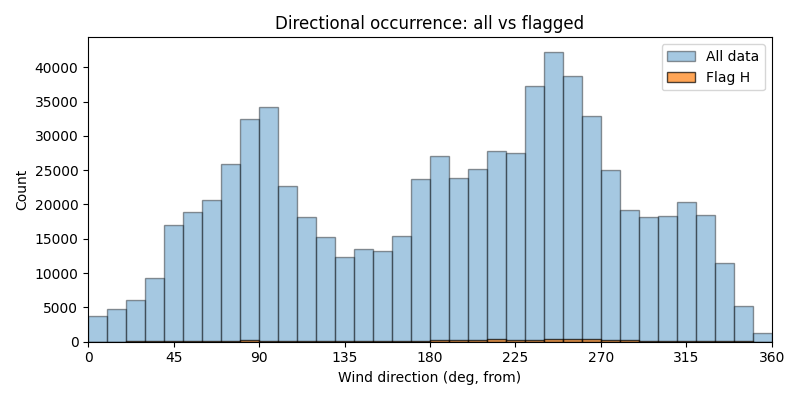

In [136]:
plot_direction_overlay(df, flag_value="H", ws_min=0.5, bin_width=10)

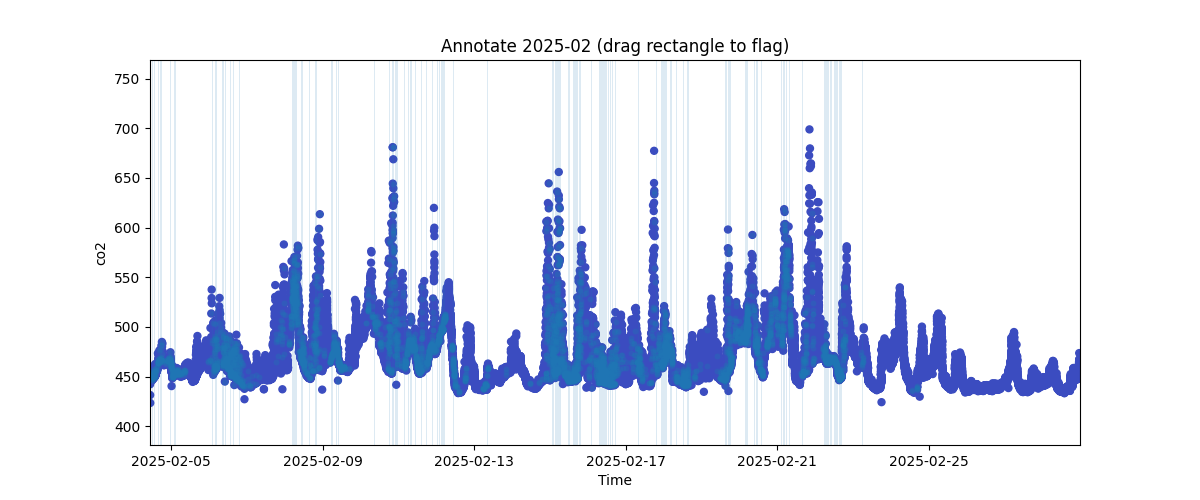

In [134]:
fig = annotate_month(
    df_site, flag,
    year=2025, month=2,
    ws_max=2,
    wd_ranges=((45, 90),),
    overlay_wind=True,
    auto_flag_wind=False,   # set True if you want those auto-flagged
    shade_wind=True
)

In [ ]:
# Add Manual_Flag column to original df
df_flagged = df.with_columns(pl.Series("Manual_Flag", flag))

# Percentage of flagged points
print("Percentage of flagged points:", 100 * df_flagged.get_column("Manual_Flag").sum() / df_flagged.height, "%")
df_flagged.filter(pl.col("Manual_Flag") != 0).tail()

Percentage of flagged points: 0.0 %


#Datetime,Year,Month,Day,Hour,Minute,Second,DecimalDate,co2,h2o,pressure,sensor_temperature,ws,wd,Flag,Manual_Flag
datetime[μs],i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,str,i8


In [128]:
output_path = os.path.join(PIPELINE_DATA_DIRECTORY, "manual_flagging")
ensure_data_dir(output_path)
df_flagged.write_parquet(f"{output_path}/{site}_manually_flagged.parquet")